# Task 2 — Customer Segmentation Analysis

### Objective
Apply RFM analysis and K-Means clustering to segment an e-commerce customer base according to purchasing behaviour and develop actionable marketing strategies for each customer segment.




## 1. Import Libraries

The required Python libraries are imported for data manipulation, statistical analysis, visualization, feature scaling, and K-Means clustering.


In [1]:
import sys
!{sys.executable} -m pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import display

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load the Dataset

The Online Retail dataset is loaded from the Excel file. The dataset contains transaction-level information such as invoice number, quantity, invoice date, unit price, customer ID, and country.


In [3]:
import sys
!{sys.executable} -m pip install openpyxl

In [4]:
file_path = r"C:\Users\HP\OneDrive\Desktop\Online Retail.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


Dataset loaded successfully!
Dataset shape: (541909, 8)


## 3. Initial Dataset Inspection

The first few records, column names, data types, and dataset structure are inspected to understand the available variables before cleaning and analysis.


In [5]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())


Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str



First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom



Last 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France


## 4. Missing Values and Duplicate Records

Missing values and duplicate rows are checked because incomplete customer identifiers and repeated transactions can affect customer-level analysis and clustering results.


In [6]:
print("Missing values by column:")
display(df.isna().sum().to_frame("Missing Values"))

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")


Missing values by column:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Number of duplicate rows: 5,268


### Observation

The dataset contains missing values, particularly in `CustomerID`, which is essential for customer segmentation. Duplicate records are also checked before further processing. Since RFM analysis requires a reliable customer identifier, transactions without a customer ID will be excluded from the customer-level analysis.


## 5. Data Cleaning

The transaction date is converted to datetime format. Cancelled invoices are identified using invoice numbers beginning with `C`. Transactions with missing customer IDs, non-positive quantities, and non-positive unit prices are removed because they do not represent valid positive sales for this customer segmentation analysis.


In [7]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Count cancelled invoices
cancelled_count = df["InvoiceNo"].astype(str).str.startswith("C").sum()
print(f"Cancelled invoice rows: {cancelled_count:,}")

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

# Remove records without CustomerID
df = df.dropna(subset=["CustomerID"]).copy()

# Remove invalid quantity and price values
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Cleaned dataset shape:", df.shape)


Cancelled invoice rows: 9,288
Cleaned dataset shape: (392692, 8)


## 6. Create Total Purchase Amount

A transaction-level purchase value is calculated as:

**Total Amount = Quantity × Unit Price**

This value is used to measure the monetary contribution of each customer.


In [8]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

display(df[["InvoiceNo", "Quantity", "UnitPrice", "TotalAmount"]].head())


,InvoiceNo,Quantity,UnitPrice,TotalAmount
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


## 7. Customer-Level Descriptive Statistics

The cleaned transaction data is aggregated at customer level. Three important behavioural measures are calculated:

- **Average Purchase Value:** average value of a customer's invoices.
- **Purchase Frequency:** number of unique invoices/orders made by the customer.
- **Customer Lifetime Value (CLV):** total monetary value generated by the customer during the available observation period.


In [9]:
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Average_Purchase_Value=("TotalAmount", "mean"),
          Purchase_Frequency=("InvoiceNo", "nunique"),
          Customer_Lifetime_Value=("TotalAmount", "sum")
      )
      .reset_index()
)

print("Customer-level dataset shape:", customer_summary.shape)
display(customer_summary.describe().T)


Customer-level dataset shape: (4338, 4)


,count,mean,std,min,25%,50%,75%,max
CustomerID,"4,338.00","15,300.41","1,721.81","12,346.00","13,813.25","15,299.50","16,778.75","18,287.00"
Average_Purchase_Value,"4,338.00",68.38,"1,467.92",2.14,12.39,17.76,24.88,"77,183.60"
Purchase_Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Customer_Lifetime_Value,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02"


### Observation

The customer-level summary shows substantial variation in purchasing behaviour. Customers differ in average transaction value, number of purchases, and total value generated. This variation provides a suitable basis for customer segmentation.


## 8. RFM Analysis

RFM analysis summarizes customer purchasing behaviour using three features:

- **Recency:** how recently a customer purchased.
- **Frequency:** how often a customer purchased.
- **Monetary:** how much a customer spent.

These three behavioural dimensions are used as the primary features for K-Means clustering.


In [10]:
# Use the day after the latest transaction as the reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("TotalAmount", "sum")
      )
      .reset_index()
)

print("Reference date:", reference_date.date())
display(rfm.head())


Reference date: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
0,"12,346.00",326,1,"77,183.60"
1,"12,347.00",2,7,"4,310.00"
2,"12,348.00",75,4,"1,797.24"
3,"12,349.00",19,1,"1,757.55"
4,"12,350.00",310,1,334.40


## 9. RFM Descriptive Statistics

The descriptive statistics of Recency, Frequency, and Monetary value are calculated to understand the distribution and scale of the behavioural features before clustering.


In [11]:
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02"


### Observation

The RFM statistics show that customers have different levels of recency, purchasing frequency, and monetary contribution. These differences are the behavioural patterns that K-Means will use to create distinct customer segments.


## 10. RFM Feature Distribution

The distributions of Recency, Frequency, and Monetary value are visualized to identify differences in customer behaviour and potential skewness before standardization.


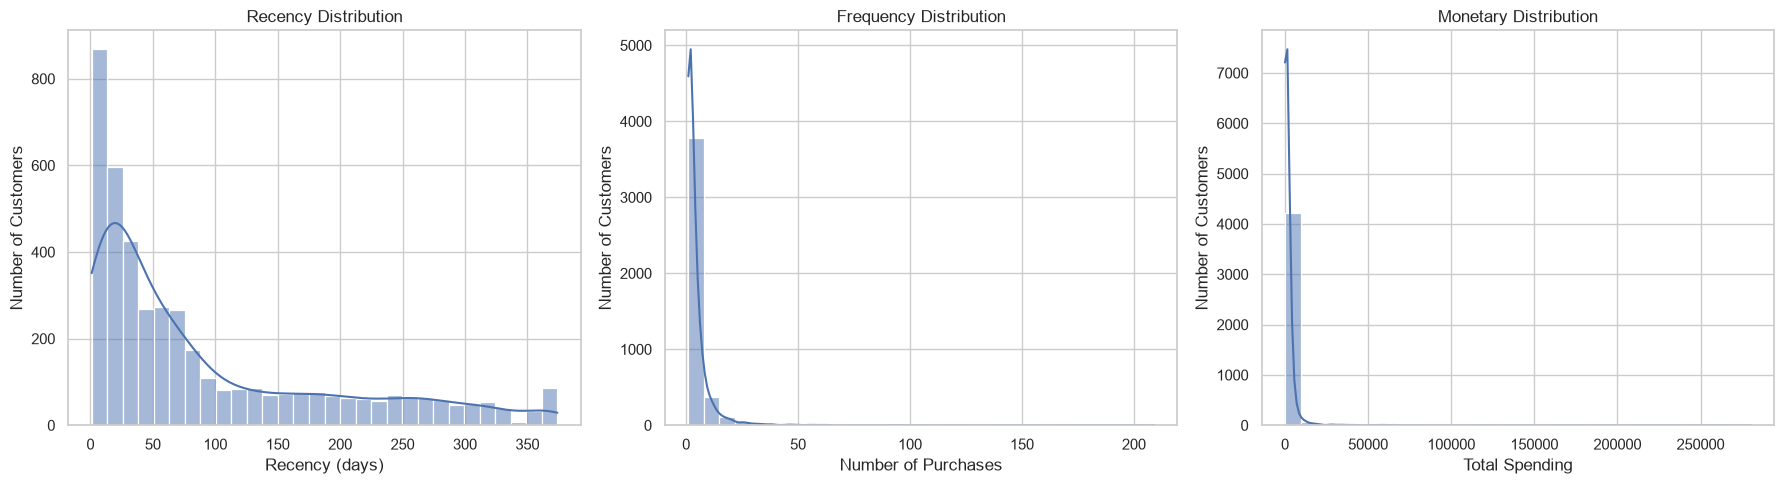

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("Number of Customers")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Purchases")
axes[1].set_ylabel("Number of Customers")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()


### Observation

The RFM distributions show that customer behaviour is not uniform. Most customers are concentrated in lower-frequency and lower-monetary ranges, while a smaller group contributes substantially more purchases and spending. Recency also varies across customers, making it useful for distinguishing recently active customers from less recent customers.


## 11. Standardize RFM Features

K-Means uses distance calculations, so features with larger numerical scales can dominate the clustering process. `StandardScaler` transforms each RFM feature to a comparable scale with a mean close to 0 and a standard deviation close to 1.


In [13]:
rfm_features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[rfm_features])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features,
    index=rfm.index
)

display(rfm_scaled_df.head())


,Recency,Frequency,Monetary
0,2.33,-0.43,8.36
1,-0.91,0.35,0.25
2,-0.18,-0.04,-0.03
3,-0.74,-0.43,-0.03
4,2.17,-0.43,-0.19


## 12. Elbow Method

The Elbow Method is used to determine a suitable number of clusters. K-Means is fitted for different values of K, and the within-cluster sum of squares (inertia) is recorded. The point where the decrease in inertia begins to slow down is considered a useful candidate for K.


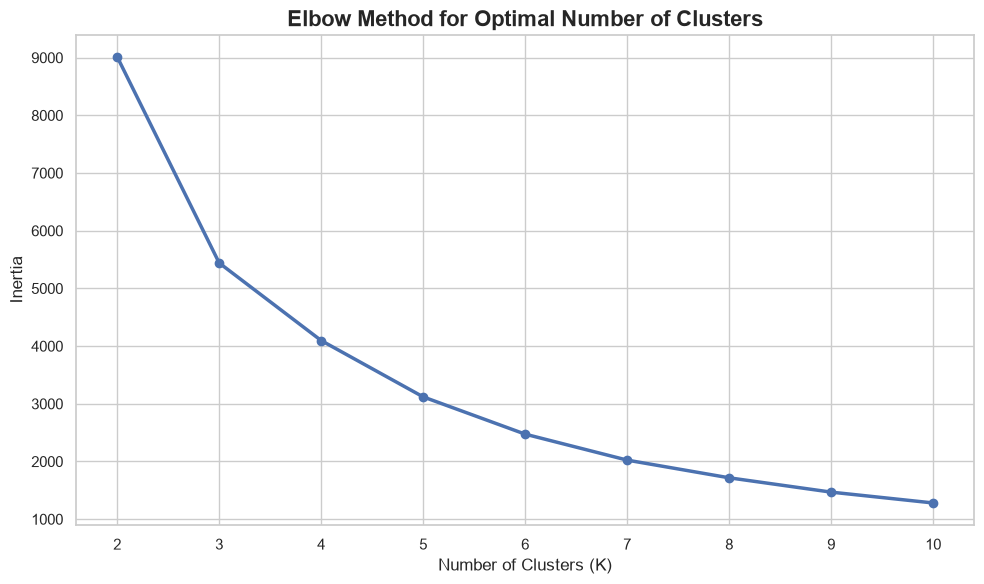

In [14]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker="o", linewidth=2.5)
plt.title("Elbow Method for Optimal Number of Clusters", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()


### Observation

The inertia decreases as the number of clusters increases. The elbow point provides a practical balance between model simplicity and the amount of within-cluster variation explained. The selected K should be based on the visible bend in the curve and the interpretability of the resulting customer groups.


## 13. Apply K-Means Clustering

Based on the Elbow Method, the clustering model below uses **K = 4** to create four customer segments. A fixed `random_state` ensures reproducible results.


In [15]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Number of clusters:", optimal_k)
print("\nCustomers per cluster:")
display(rfm["Cluster"].value_counts().sort_index().to_frame("Customer Count"))


Number of clusters: 4

Customers per cluster:


,Customer Count
Cluster,
0,3054
1,1067
2,13
3,204


## 14. Cluster Visualization — Recency vs Frequency

The first scatter plot compares Recency and Frequency for the identified customer segments. This helps visualize how customer activity differs across clusters.


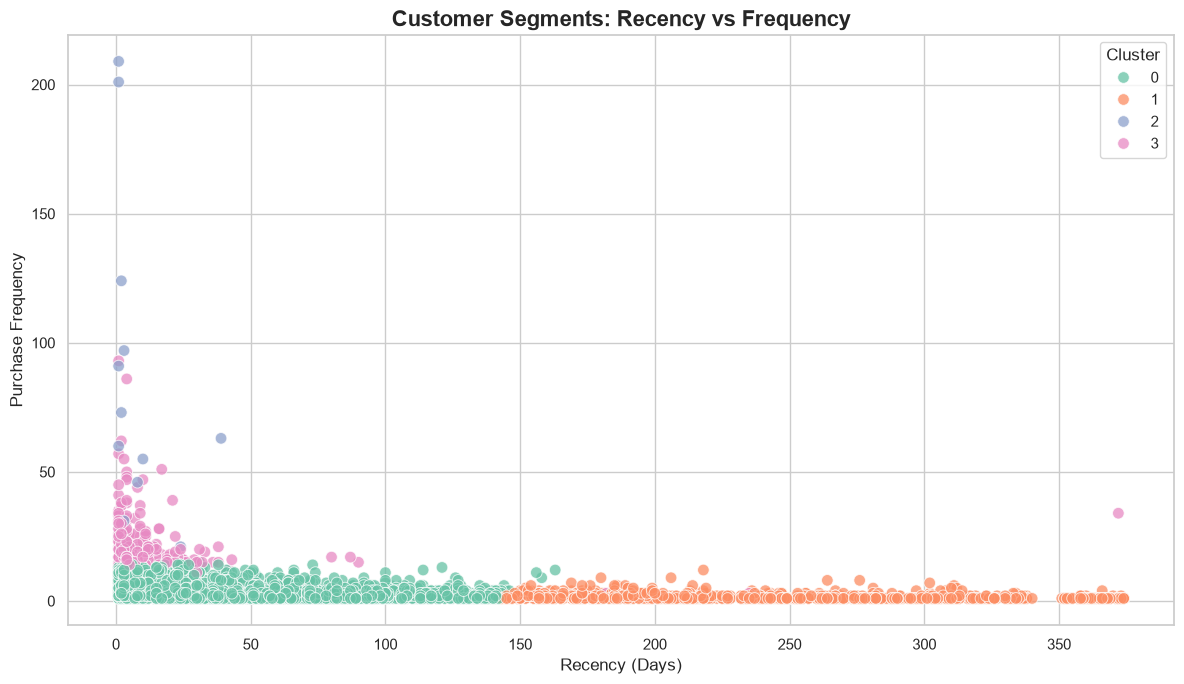

In [16]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.75
)

plt.title("Customer Segments: Recency vs Frequency", fontsize=16, fontweight="bold")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### Observation

The clusters occupy different regions of the Recency–Frequency space. This indicates that customers differ not only in how recently they purchased, but also in how frequently they purchase. These differences support the use of separate engagement strategies for different customer groups.


## 15. Cluster Visualization — Frequency vs Monetary

The second scatter plot compares purchase frequency with total monetary contribution. This helps identify customers who purchase frequently and/or generate high value.


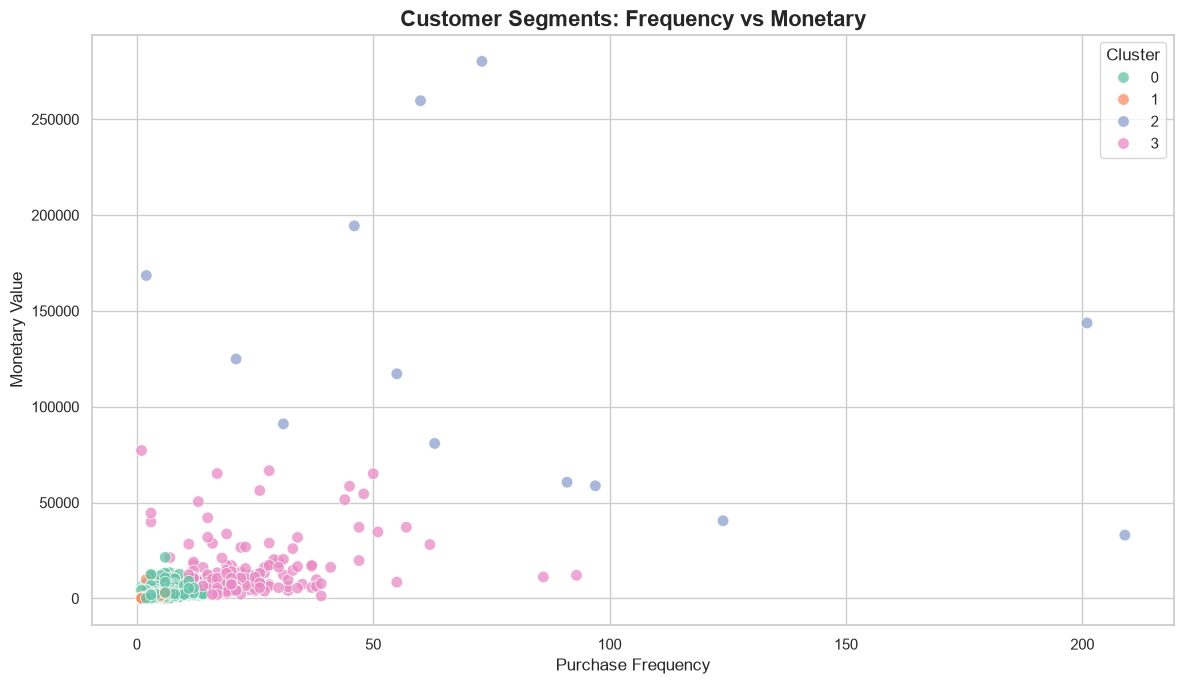

In [17]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.75
)

plt.title("Customer Segments: Frequency vs Monetary", fontsize=16, fontweight="bold")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### Observation

The Frequency–Monetary plot shows clear differences in customer value. Some clusters contain customers with relatively high purchase frequency and spending, while others contain lower-value customers. This distinction is important for prioritizing retention and promotional efforts.


## 16. Cluster Profile

The mean RFM values are calculated for each cluster. These profiles are used to understand the behavioural characteristics of the customer segments.


In [18]:
cluster_profile = (
    rfm.groupby("Cluster")[rfm_features]
       .mean()
       .round(2)
)

cluster_profile["Customer_Count"] = rfm["Cluster"].value_counts().sort_index()

display(cluster_profile)


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.70,3.68,"1,353.63",3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,"127,187.96",13
3,15.50,22.33,"12,690.50",204


### Observation

The cluster profiles provide a clear comparison of customer behaviour. Lower Recency indicates more recent activity, while higher Frequency and Monetary values indicate more frequent purchasing and greater customer value. These metrics form the basis for assigning meaningful business descriptions to each segment.


## 17. Number of Customers per Cluster

The number of customers in each cluster is visualized to understand the relative size of each segment.


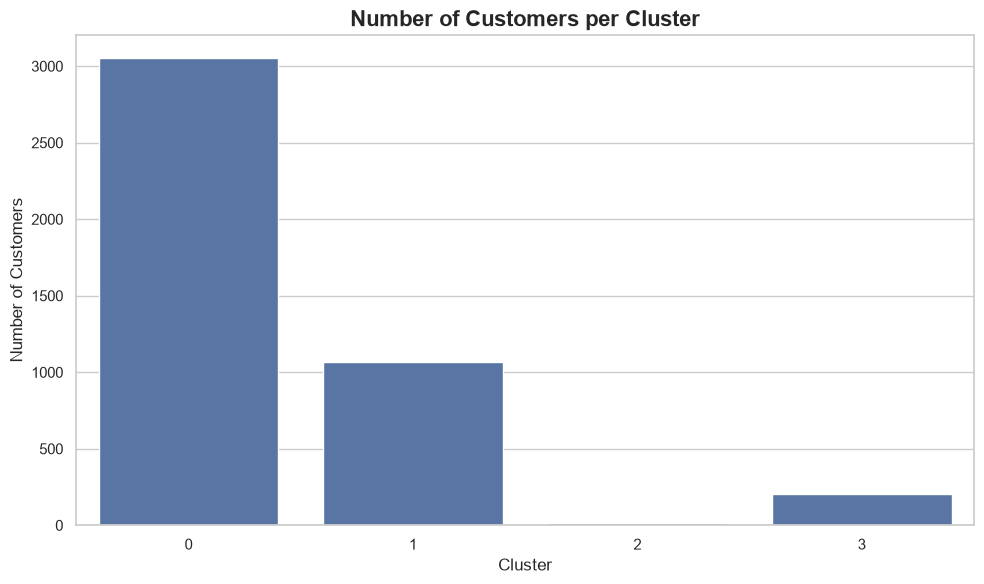

In [19]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster", fontsize=16, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


### Observation

The cluster sizes are not necessarily equal, which is expected because K-Means groups customers according to behavioural similarity rather than forcing equal-sized segments. The size of each cluster should be considered when allocating marketing resources.


## 18. Business Segment Interpretation

The following interpretation uses the cluster profile to translate statistical groups into actionable customer types:

- **High-value / loyal customers:** relatively low Recency with high Frequency and Monetary value.
- **Recent customers:** low Recency with moderate purchasing activity and spending.
- **At-risk customers:** relatively high Recency combined with previously meaningful Frequency and/or Monetary value.
- **Low-engagement customers:** relatively high Recency with low Frequency and Monetary value.

The exact cluster number should be mapped to these descriptions using the cluster profile table above rather than assuming that a particular number always represents a particular segment.


## 19. Marketing Recommendations

### High-value / Loyal Customers
- Introduce loyalty rewards and VIP benefits.
- Provide early access to new products or exclusive offers.
- Use personalized recommendations to increase retention and lifetime value.

### Recent / Promising Customers
- Encourage a second or repeat purchase through personalized follow-up campaigns.
- Recommend related products based on their previous purchases.
- Use limited-time incentives to build purchasing frequency.

### At-risk Customers
- Run win-back campaigns targeted at customers who have not purchased recently.
- Offer personalized discounts or product reminders based on previous spending.
- Prioritize high-value at-risk customers for stronger retention incentives.

### Low-engagement Customers
- Use low-cost email or remarketing campaigns to test reactivation.
- Provide simple introductory offers rather than expensive incentives.
- Avoid allocating disproportionate marketing resources unless engagement improves.


## 20. Final Insights

1. Customer purchasing behaviour varies substantially across Recency, Frequency, and Monetary dimensions.
2. RFM analysis provides a compact behavioural representation of the customer base.
3. Standardization is necessary before K-Means because the RFM variables have different numerical scales.
4. The Elbow Method provides a practical basis for selecting the number of customer segments.
5. The resulting clusters can be translated into actionable groups such as loyal/high-value, recent/promising, at-risk, and low-engagement customers.
6. Marketing resources can therefore be prioritized according to customer value and engagement rather than treating every customer identically.


# Conclusion

RFM analysis combined with K-Means clustering successfully segments the e-commerce customer base according to purchasing behaviour. The segmentation identifies meaningful differences in customer recency, purchasing frequency, and monetary contribution.

From a business perspective, the analysis can support targeted retention, loyalty, reactivation, and cross-selling strategies. High-value customers should receive stronger retention and loyalty initiatives, while at-risk customers should be prioritized for win-back campaigns. Lower-engagement customers can be approached through cost-efficient reactivation campaigns.

Overall, customer segmentation enables the business to allocate marketing resources more effectively and build strategies around measurable customer behaviour.
